In [7]:
import lightkurve as lk
import matplotlib.pyplot as plt

lc = lk.search_lightcurve("Kepler-10", mission="Kepler").download()

lc = lc.remove_nans().flatten()

print(lc)
print(lc.columns)

/Users/evanhoyt/exoplanet-env/lib/python3.9/site-packages/lightkurve/search.py:420: LightkurveWarning: Warning: 50 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


       time             flux      ...   pos_corr1      pos_corr2   
                                  ...      pix            pix      
------------------ -------------- ... -------------- --------------
200.32408500967722  9.9994334e-01 ... -8.9440849e-03  3.7062202e-02
 200.3247661127025  1.0001716e+00 ... -8.9426376e-03  3.7056953e-02
200.32544721572776  1.0000770e+00 ... -8.9411894e-03  3.7051704e-02
200.32612831898587  9.9974265e-01 ... -8.9397421e-03  3.7046455e-02
 200.3268094220184  9.9967919e-01 ... -8.9382939e-03  3.7041202e-02
 200.3274905250437  9.9984673e-01 ... -8.9368466e-03  3.7035953e-02
200.32817172830255  9.9991212e-01 ... -8.9353984e-03  3.7030704e-02
200.32885283132782  1.0000846e+00 ... -8.9339502e-03  3.7025455e-02
 200.3295339343531  1.0000615e+00 ... -8.9325029e-03  3.7020203e-02
200.33021513761196  1.0000673e+00 ... -8.9310547e-03  3.7014954e-02
               ...            ... ...            ...            ...
230.29327240424027  1.0000023e+00 ...  1.7958542

In [8]:
df = lc.to_pandas()
df.head()

,flux,flux_err,quality,timecorr,centroid_col,centroid_row,cadenceno,sap_flux,sap_flux_err,sap_bkg,...,psf_centr1,psf_centr1_err,psf_centr2,psf_centr2_err,mom_centr1,mom_centr1_err,mom_centr2,mom_centr2_err,pos_corr1,pos_corr2
time,,,,,,,,,,,,,,,,,,,,,
200.324085,0.999943,0.000203,0,0.002622,655.633175,250.328890,122650,556295.3750,111.053574,3416.366455,...,NaN,NaN,NaN,NaN,655.633175,0.000201,250.328890,0.000286,-0.008944,0.037062
200.324766,1.000172,0.000203,0,0.002622,655.633607,250.325929,122651,556420.5625,111.061646,3416.826660,...,NaN,NaN,NaN,NaN,655.633607,0.000201,250.325929,0.000286,-0.008943,0.037057
200.325447,1.000077,0.000203,0,0.002622,655.633193,250.327724,122652,556367.7500,111.055534,3417.287354,...,NaN,NaN,NaN,NaN,655.633193,0.000201,250.327724,0.000286,-0.008941,0.037052
200.326128,0.999743,0.000203,0,0.002622,655.632775,250.327926,122653,556183.0000,111.046555,3417.747803,...,NaN,NaN,NaN,NaN,655.632775,0.000201,250.327926,0.000286,-0.008940,0.037046
200.326809,0.999679,0.000203,0,0.002622,655.633142,250.327344,122654,556147.5000,111.039520,3418.208252,...,NaN,NaN,NaN,NaN,655.633142,0.000201,250.327344,0.000286,-0.008938,0.037041


In [9]:
df.describe()

,flux,flux_err,quality,timecorr,centroid_col,centroid_row,cadenceno,sap_flux,sap_flux_err,sap_bkg,...,psf_centr1,psf_centr1_err,psf_centr2,psf_centr2_err,mom_centr1,mom_centr1_err,mom_centr2,mom_centr2_err,pos_corr1,pos_corr2
count,43361.000000,43361.000000,43361.000000,43361.000000,43361.000000,43361.000000,43361.000000,43361.000000,43361.000000,43361.000000,...,0.0,0.0,0.0,0.0,43361.000000,4.336100e+04,43361.000000,4.336100e+04,43361.000000,43361.000000
mean,1.000001,0.000203,325.789903,0.002616,655.642936,250.293468,144499.884435,556119.500000,110.955353,3424.385498,...,NaN,NaN,NaN,NaN,655.642936,2.008800e-04,250.293468,2.862712e-04,0.001464,0.000960
std,0.000248,0.000001,1589.054638,0.000030,0.006559,0.019275,12708.674033,169.879333,0.056267,14.195884,...,NaN,NaN,NaN,NaN,0.006559,1.277281e-07,0.019275,3.085751e-07,0.007208,0.020892
min,0.996517,0.000201,0.000000,0.002535,655.627095,250.257605,122650.000000,554212.187500,110.869377,3404.774414,...,NaN,NaN,NaN,NaN,655.627095,1.996597e-04,250.257605,2.855941e-04,-0.008944,-0.034688
25%,0.999860,0.000202,0.000000,0.002601,655.637663,250.276719,133514.000000,556015.312500,110.915482,3414.666016,...,NaN,NaN,NaN,NaN,655.637663,2.008373e-04,250.276719,2.861343e-04,-0.004372,-0.016903
50%,0.999999,0.000202,0.000000,0.002629,655.641618,250.292873,144389.000000,556119.375000,110.931046,3418.645264,...,NaN,NaN,NaN,NaN,655.641618,2.008780e-04,250.292873,2.862243e-04,-0.000348,0.000334
75%,1.000142,0.000204,0.000000,0.002640,655.647833,250.310706,155253.000000,556222.375000,111.013168,3430.881348,...,NaN,NaN,NaN,NaN,655.647833,2.009164e-04,250.310706,2.863548e-04,0.006703,0.019463
max,1.013064,0.000207,10368.000000,0.002643,655.659873,250.341740,166659.000000,563362.312500,112.789680,3498.802979,...,NaN,NaN,NaN,NaN,655.659873,2.126234e-04,250.341740,3.337745e-04,0.018165,0.037122


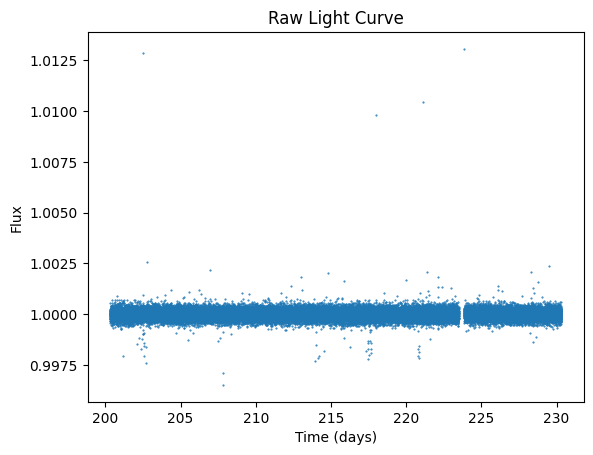

In [10]:
import matplotlib.pyplot as plt

plt.plot(lc.time.value, lc.flux.value, '.', markersize=1)
plt.xlabel("Time (days)")
plt.ylabel("Flux")
plt.title("Raw Light Curve")
plt.show()

In [14]:
lc_clean = lc[lc.quality == 0]
df = lc_clean.to_pandas()
df.head()

,flux,flux_err,quality,timecorr,centroid_col,centroid_row,cadenceno,sap_flux,sap_flux_err,sap_bkg,...,psf_centr1,psf_centr1_err,psf_centr2,psf_centr2_err,mom_centr1,mom_centr1_err,mom_centr2,mom_centr2_err,pos_corr1,pos_corr2
time,,,,,,,,,,,,,,,,,,,,,
200.324085,0.999943,0.000203,0,0.002622,655.633175,250.328890,122650,556295.3750,111.053574,3416.366455,...,NaN,NaN,NaN,NaN,655.633175,0.000201,250.328890,0.000286,-0.008944,0.037062
200.324766,1.000172,0.000203,0,0.002622,655.633607,250.325929,122651,556420.5625,111.061646,3416.826660,...,NaN,NaN,NaN,NaN,655.633607,0.000201,250.325929,0.000286,-0.008943,0.037057
200.325447,1.000077,0.000203,0,0.002622,655.633193,250.327724,122652,556367.7500,111.055534,3417.287354,...,NaN,NaN,NaN,NaN,655.633193,0.000201,250.327724,0.000286,-0.008941,0.037052
200.326128,0.999743,0.000203,0,0.002622,655.632775,250.327926,122653,556183.0000,111.046555,3417.747803,...,NaN,NaN,NaN,NaN,655.632775,0.000201,250.327926,0.000286,-0.008940,0.037046
200.326809,0.999679,0.000203,0,0.002622,655.633142,250.327344,122654,556147.5000,111.039520,3418.208252,...,NaN,NaN,NaN,NaN,655.633142,0.000201,250.327344,0.000286,-0.008938,0.037041


In [12]:
lc_clean = lc[lc.quality == 0]